In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('Data/data_preprocessing.csv', index_col='Date', parse_dates=True)
df.head()

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-01,0.0,24.12,66.46,26.87
1985-01-02,0.0,24.27,66.08,26.60
1985-01-03,0.1,25.02,61.42,22.44
1985-01-04,0.2,25.26,60.54,22.89
1985-01-05,0.0,25.05,59.92,24.88


In [3]:
# Sắp xếp và kiểm tra dữ liệu
df = df.sort_index()

# kiểm tra liên tục thời gian
print(df.index.to_series().diff().value_counts().head())

Date
1 days    12204
Name: count, dtype: int64


In [4]:
# Chọn biến đầu vào & mục tiêu
features = ['Precipitation', 'Relative Humidity', 'Wind Speed']
target = 'Temperature'

X = df[features]
y = df[target]

In [5]:
# Chia tập dữ liệu: 70% train, 15% validation, 15% test
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8543, 3)
y_train shape: (8543,)
X_val shape: (1830, 3)
y_val shape: (1830,)
X_test shape: (1832, 3)
y_test shape: (1832,)


In [7]:
# Chuẩn hóa dữ liệu
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

In [8]:
# Hàm tạo chuỗi dữ liệu > Dự đoán ngày tiếp theo
def create_sequences(X, y, time_step):
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_step):
        X_seq.append(X[i:i + time_step])
        y_seq.append(y[i + time_step])
        
    return np.array(X_seq), np.array(y_seq)

In [9]:
# Xác định time_step = 30 
time_step = 30

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_step)
X_val_seq, y_val_seq     = create_sequences(X_val_scaled, y_val_scaled, time_step)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled, time_step)

#### Xây dựng mô hình

In [10]:
# Khai báo thư viện
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

In [11]:
# Khởi tạo lớp LTCCell 
# from keras.saving import register_keras_serializable

# @register_keras_serializable()
class LTCCell(layers.Layer):
    def __init__(self, units, **kwargs):
        super(LTCCell, self).__init__(**kwargs)
        self.units = units
    # Khai báo state_size & output_size
    @property
    def state_size(self): # Kích thước trạng thái ẩn
        return self.units
    @property
    def output_size(self): # Kích thước đầu ra
        return self.units
    # Tạo các tham số (weights)
    def build(self, input_shape):
        input_dim = int(input_shape[-1])
# Trọng số cho input
        self.W = self.add_weight(
            shape=(input_dim, self.units),
            initializer='glorot_uniform',
            trainable=True,
            name='kernel_W'
        )
# Trọng số hồi quy
        self.U = self.add_weight(
            shape=(self.units, self.units),
            initializer='orthogonal',
            trainable=True,
            name='recurrent_kernel_U'
        )
# Bias
        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
            name='bias_b'
        )
# Tham số τ (time constant) 
# τ lớn → cập nhật chậm
# τ nhỏ → cập nhật nhanh
        self.tau = self.add_weight(
            shape=(self.units,),
            initializer='ones',
            trainable=True,
            name='time_constant_tau'
        )
# Hệ số khuếch đại
        self.gain = self.add_weight(
            shape=(self.units,),
            initializer='ones',
            trainable=True,
            name='gain'
        )
        super(LTCCell, self).build(input_shape)
        # Hàm cập nhật trạng thái (call)
    def call(self, inputs, states):
        prev_output = states[0] 
# Tính h = Wx + Uh + b
        h = tf.matmul(inputs, self.W) + tf.matmul(prev_output, self.U) + self.b
# Giới hạn τ để tránh giá trị quá lớn/nhỏ
        tau_clipped = tf.clip_by_value(self.tau, 0.1, 10.0)
# α = 1/τ
        alpha = 1.0 / tau_clipped
# Hàm kích hoạt
        activation = tf.tanh(self.gain * h)
# Công thức cập nhật động học liên tục
        output = (1 - alpha) * prev_output + alpha * activation
        return output, [output]

In [12]:
# Khởi tạo trạng thái ban đầu
def get_initial_state(self, inputs=None, batch_size=None, dtype=None):
    if batch_size is None:
        batch_size = tf.shape(inputs)[0]
    if dtype is None:
         dtype = tf.float32
        
    return [tf.zeros((batch_size, self.units), dtype=dtype)]

In [13]:
# # Lưu mô hình
# def get_config(self):
#         config = super(LTCCell, self).get_config()
#         config.update({'units': self.units})
#         return config

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RNN, Dense, Input

input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

model_hybrid = Sequential([
    Input(shape=input_shape),

    # LSTM học phụ thuộc dài hạn
    LSTM(64, return_sequences=True),

    # LNN xử lý động học liên tục
    RNN(LTCCell(64), return_sequences=False),

    Dense(1)
])

In [15]:
model_hybrid.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [16]:
model_hybrid.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rnn (RNN)                            │ (None, 64)                  │           8,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_hybrid = model_hybrid.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0204 - mae: 0.1011 - val_loss: 0.0117 - val_mae: 0.0870
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0105 - mae: 0.0801 - val_loss: 0.0175 - val_mae: 0.1050
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0106 - mae: 0.0802 - val_loss: 0.0074 - val_mae: 0.0678
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0098 - mae: 0.0770 - val_loss: 0.0067 - val_mae: 0.0642
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0095 - mae: 0.0758 - val_loss: 0.0064 - val_mae: 0.0625
Epoch 6/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0097 - mae: 0.0767 - val_loss: 0.0075 - val_mae: 0.0676
Epoch 7/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0091 - mae: 0.0742 - val_loss: 0.0073 - val_mae: 0.0664
Epoch 8/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0089 - mae: 0.0735 - val_loss: 0.0066 - val_mae: 0.0630
Epoch 9/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/

In [19]:
# Dự đoán trên tập kiểm tra
y_pred_scaled = model_hybrid.predict(X_test_seq)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step  


In [20]:
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test_seq)

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 1.5068176991240592
RMSE: 1.2275250299379068
MAE : 0.9612248467499356
R2  : 0.43555185823260023


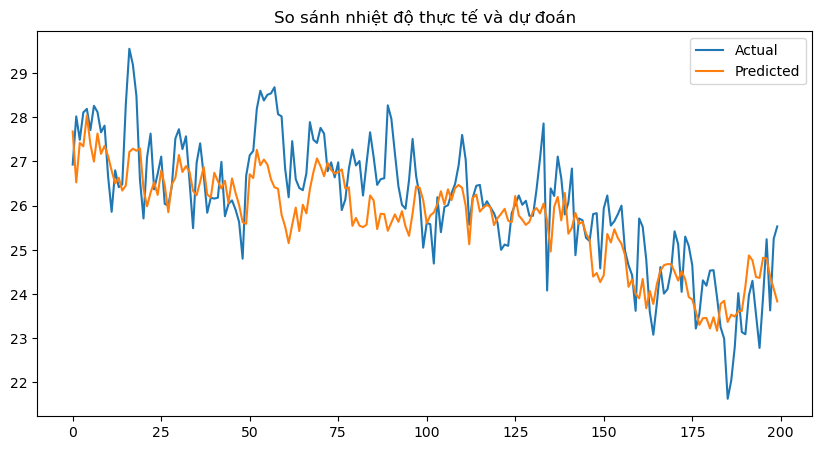

In [22]:
 # Vẽ biểu đồ so sánh Thực tế vs Dự đoán
plt.figure(figsize=(10,5))
plt.plot(y_test_original[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("So sánh nhiệt độ thực tế và dự đoán")
plt.show()

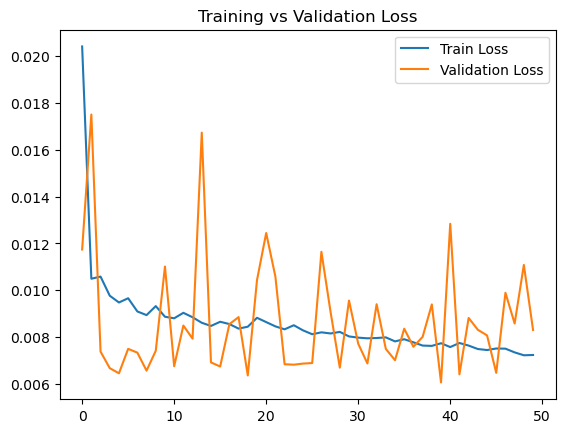

In [23]:
# Vẽ biểu đồ Loss trong quá trình train
plt.plot(history_hybrid.history['loss'], label='Train Loss')
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [24]:
print("===== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH =====")
print(f"Sai số bình phương trung bình (MSE): {mse:.4f}")
print(f"Căn bậc hai sai số (RMSE): {rmse:.4f} °C")
print(f"Sai số tuyệt đối trung bình (MAE): {mae:.4f} °C")
print(f"Hệ số xác định (R²): {r2:.4f}")

===== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH =====
Sai số bình phương trung bình (MSE): 1.5068
Căn bậc hai sai số (RMSE): 1.2275 °C
Sai số tuyệt đối trung bình (MAE): 0.9612 °C
Hệ số xác định (R²): 0.4356


In [25]:
comparison_df = pd.DataFrame({
    "Nhiệt độ thực tế (°C)": y_test_original.flatten(),
    "Nhiệt độ dự đoán (°C)": y_pred.flatten()
})

comparison_df["Sai số"] = comparison_df["Nhiệt độ thực tế (°C)"] - comparison_df["Nhiệt độ dự đoán (°C)"]
comparison_df["Sai số tuyệt đối"] = comparison_df["Sai số"].abs()

print("===== BẢNG SO SÁNH GIÁ TRỊ THỰC TẾ VÀ DỰ ĐOÁN =====")
display(comparison_df.round(2).head(10))

===== BẢNG SO SÁNH GIÁ TRỊ THỰC TẾ VÀ DỰ ĐOÁN =====


,Nhiệt độ thực tế (°C),Nhiệt độ dự đoán (°C),Sai số,Sai số tuyệt đối
0,26.93,27.680000,-0.75,0.75
1,28.02,26.530001,1.49,1.49
2,27.49,27.420000,0.07,0.07
3,28.11,27.340000,0.77,0.77
4,28.19,28.040001,0.15,0.15
5,27.71,27.389999,0.32,0.32
6,28.26,27.000000,1.26,1.26
7,28.12,27.629999,0.49,0.49
8,27.66,27.170000,0.49,0.49
9,27.81,27.350000,0.46,0.46


In [26]:
# Lấy index tương ứng với tập test gốc
test_index = df.index[-len(y_test_seq):]

comparison_df = pd.DataFrame({
    "Ngày": test_index,
    "Nhiệt độ thực tế (°C)": y_test_original.flatten(),
    "Nhiệt độ dự đoán (°C)": y_pred.flatten()
})

comparison_df.set_index("Ngày", inplace=True)
comparison_df.head(20)

print("===== SO SÁNH THEO TỪNG NGÀY =====")
display(comparison_df.round(2).head(20))

===== SO SÁNH THEO TỪNG NGÀY =====


,Nhiệt độ thực tế (°C),Nhiệt độ dự đoán (°C)
Ngày,,
2013-06-26,26.93,27.680000
2013-06-27,28.02,26.530001
2013-06-28,27.49,27.420000
2013-06-29,28.11,27.340000
2013-06-30,28.19,28.040001
2013-07-01,27.71,27.389999
2013-07-02,28.26,27.000000
2013-07-03,28.12,27.629999
2013-07-04,27.66,27.170000


In [27]:
mape = np.mean(np.abs((y_test_original - y_pred) / y_test_original)) * 100
print(f"Sai số phần trăm trung bình (MAPE): {mape:.2f}%")

Sai số phần trăm trung bình (MAPE): 3.62%
